# RQ1 — Consolidated cross-scheme analysis

**Question:** Does the geometric relationship between two behavioural steering
vectors predict how those behaviours compose under joint injection?

This notebook *replaces* the binned-regime framing used in the earlier four
notebooks (`composition_anal`, `phase12_vs_phase125_audit`,
`signed_cosine_predicts_suppression`, `per_axis_deep_dive`) with a single
consolidated cross-scheme dataframe and one nested-OLS analysis on a continuous
outcome. Three things from the earlier work are now treated as **settled**:

1. **Binned regimes are out as a regression target.** With 8 behaviours we have
   ≤28 pairs and 3–7 additives. The binary logistic on `is_additive` is wildly
   overfit (in-sample AUC ≈ 0.83, LOO ≈ 0.61, often below random).
   Regime labels are kept as *descriptive colour* only.

2. **The Phase 12 "|cos| → emergence" signal was a dose-confound artefact.**
   Under `normalize=False`, ‖δ‖ = α·√(2(1+cos)), so cos is mechanically tied to
   push magnitude (r ≈ 0.995). High-cos pairs were over-dosed → coherence
   collapsed → ratio-based regime classification read the gibberish-ratings as
   emergent/mixed. The mediation chain cos→‖δ‖→coh→regime is documented in
   `phase12_vs_phase125_audit`.

3. **The real signal is signed cos → a continuous expression metric.**
   r(signed cos, mean_joint_abs) = +0.65 on Phase 12.5 (perm p ≈ 5e-4,
   Bonferroni-clear, LOO-stable). Replaces |cos| (r = +0.34, p = 0.08).
   Sign matters: aligned vectors co-express; antipodal vectors mutually suppress.

**The open question this notebook tackles:** we have *not* cleanly separated
"geometry per se" from the mechanical effect of the injection scheme.
Per-axis dose is a closed-form function of cos under all three schemes:

| scheme | ‖δ‖ | per-axis push onto v̂_i |
|---|---|---|
| `normFalse` (v1, Phase 12, α=4) | α·√(2(1+cos)) | α·(1+cos) |
| `normTrue` (v2, Phase 12.5, α=4.5) | α | α·√((1+cos)/2) |
| `per_axis` (v3, Phase 15.16, α=4.5) | α·√(2/(1+cos)) | α |

So cos → expression is *partly tautological*: how tautological depends on which
scheme we picked. Probe 1 in `per_axis_deep_dive` showed
partial r(cos | mean_single_abs) = **+0.45 under v125 vs +0.03 under v3** — the
scheme determines whether cos carries independent signal. We treat that
scheme-dependence as the finding, not as noise.

**Plan.**
- §1: build a tidy long-format frame (one row per (pair, scheme)) with the
  primary outcome `mean_joint_abs`, the controls, and the closed-form mechanical
  push per scheme. Filter `coh_steered < 30`.
- §2: sanity checks — replicate the |cos| vs signed cos contrast and the
  partial-r scheme contrast on the consolidated frame, plus a 3-panel scatter
  with mechanical baseline overlaid.
- §3: nested OLS (M0 → M3) predicting `mean_joint_abs`. M2's signed-cos
  coefficient and M3's `cos × scheme` interaction are the answer to RQ1.
  Permutation + bootstrap for inference because n ≈ 22–28 per scheme.
- §4: read of the numbers + recommended next step.


In [1]:
# Imports + paths + rng
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
RNG  = np.random.default_rng(0)

SCHEME_PATHS = {
    "normFalse": REPO / "results/composition/v1_phase12_normFalse_a4/scoring/summary.json",
    "normTrue":  REPO / "results/composition/v2_phase125_normTrue_a4.5/scoring/summary.json",
    "per_axis":  REPO / "results/composition/v3_phase1516_perAxis_a4.5/scoring/summary.json",
}
SEM_PATH = REPO / "results/semantic_similarity.json"

for k, p in SCHEME_PATHS.items():
    assert p.exists(), f"missing {k}: {p}"
assert SEM_PATH.exists(), SEM_PATH
print("All inputs present.")

All inputs present.


## §1 — Build the consolidated tidy dataframe

One row per `(pair, scheme)`. We pull the four delta fields (joint and single,
trait_a and trait_b), the steered coherence, the cos, the regime label
(descriptive only), and compute:

- `mean_joint_abs = 0.5·(|δ_a_joint| + |δ_b_joint|)` — **primary outcome**.
  Chosen over `supp_mean` because `supp_mean` is a ratio and blows up when
  `delta_single ≈ 0` (e.g. broken traits); `mean_joint_abs` is the absolute
  expression in the joint condition and has no such instability.
- `mean_single_abs = 0.5·(|δ_a_single| + |δ_b_single|)` — single-trait amplitude.
  Controls for the trivial "these traits steer strongly individually" baseline.
- `min/max_single_abs` — for sensitivity (does the weaker or stronger trait
  drive joint expression?).
- `mechanical_push` — closed-form per-axis push predicted by the injection
  formula for this scheme (the design's own "prediction").

We then attach `semantic_similarity` per pair from `text-embedding-3-large`
cosine on the trait descriptions, as an independent geometric control
(geometry-in-meaning, not geometry-in-activation).

In [2]:
def load_pairs(path: Path, scheme: str) -> pd.DataFrame:
    d = json.load(open(path))
    alpha = float(d["alpha"])
    rows = []
    for p in d["pairs"]:
        if p.get("status") != "ok":
            continue
        rows.append({
            "trait_a": p["trait_a"],
            "trait_b": p["trait_b"],
            "scheme":  scheme,
            "alpha":   alpha,
            "cos":     float(p["cos"]),
            "regime":  p["regime"],
            "coh_steered":    p["steered"]["coherence_mean"],
            "delta_a_single": p["delta"]["trait_a_single"],
            "delta_b_single": p["delta"]["trait_b_single"],
            "delta_a_joint":  p["delta"]["trait_a_joint"],
            "delta_b_joint":  p["delta"]["trait_b_joint"],
        })
    return pd.DataFrame(rows)


def mechanical_push(cos: np.ndarray, scheme: str, alpha: float) -> np.ndarray:
    # per-axis push of joint δ onto v̂_a (== onto v̂_b, by symmetry under (1,1))
    if scheme == "normFalse":
        return alpha * (1.0 + cos)
    if scheme == "normTrue":
        return alpha * np.sqrt(np.clip((1.0 + cos) / 2.0, 0, None))
    if scheme == "per_axis":
        return np.full_like(cos, alpha, dtype=float)
    raise ValueError(scheme)


frames = [load_pairs(p, s) for s, p in SCHEME_PATHS.items()]
df = pd.concat(frames, ignore_index=True)
df["pair"] = df.apply(lambda r: tuple(sorted([r.trait_a, r.trait_b])), axis=1)
df["pair_key"] = df["pair"].apply(lambda t: f"{t[0]}|{t[1]}")
df["cos_abs"] = df["cos"].abs()
df["mean_joint_abs"]  = 0.5 * (df["delta_a_joint"].abs()  + df["delta_b_joint"].abs())
df["mean_single_abs"] = 0.5 * (df["delta_a_single"].abs() + df["delta_b_single"].abs())
df["min_single_abs"]  = np.minimum(df["delta_a_single"].abs(), df["delta_b_single"].abs())
df["max_single_abs"]  = np.maximum(df["delta_a_single"].abs(), df["delta_b_single"].abs())
df["mechanical_push"] = df.apply(
    lambda r: mechanical_push(np.array([r["cos"]]), r["scheme"], r["alpha"])[0], axis=1)

# semantic similarity from sentence embeddings on trait descriptions
ss = json.load(open(SEM_PATH))
sem_traits = ss["traits"]
sem_mat = np.array(ss["sem_cos_matrix"])
sem_lookup = {(a, b): sem_mat[i, j]
              for i, a in enumerate(sem_traits) for j, b in enumerate(sem_traits)}
df["sem_sim"] = df.apply(
    lambda r: sem_lookup.get((r.trait_a, r.trait_b),
              sem_lookup.get((r.trait_b, r.trait_a), np.nan)), axis=1)

print(f"Raw rows: {len(df)}  (schemes: {dict(df['scheme'].value_counts())})")
print(f"NaN sem_sim rows: {df['sem_sim'].isna().sum()}")
df[["scheme","trait_a","trait_b","cos","coh_steered","mean_single_abs","mean_joint_abs","mechanical_push","sem_sim","regime"]].head(8).round(3)

Raw rows: 92  (schemes: {'normFalse': 36, 'normTrue': 28, 'per_axis': 28})
NaN sem_sim rows: 0


,scheme,trait_a,trait_b,cos,coh_steered,mean_single_abs,mean_joint_abs,mechanical_push,sem_sim,regime
0,normFalse,apathetic,confidence,0.014,55.56,26.365,34.985,4.057,0.240,dominant
1,normFalse,apathetic,evil,0.258,28.75,41.330,50.085,5.031,0.321,mixed
2,normFalse,apathetic,formality,0.015,80.87,14.665,33.730,4.060,0.246,mixed
3,normFalse,apathetic,hallucinating,-0.164,59.95,25.900,46.075,3.343,0.198,emergent
4,normFalse,apathetic,humorous,0.192,27.09,49.070,64.030,4.769,0.233,mixed
5,normFalse,apathetic,impolite,0.695,23.47,47.180,75.865,6.779,0.470,mixed
6,normFalse,apathetic,power_seeking,0.006,81.73,21.395,24.920,4.025,0.291,additive
7,normFalse,apathetic,sycophantic,0.050,43.79,51.560,47.415,4.201,0.344,mixed


### Coherence filter

Drop any `(pair, scheme)` row with `coh_steered < 30`. These are coherence
collapses where the judge overshoots on near-gibberish output (documented in
probes 5+7 of `per_axis_deep_dive`: 4 v3 "emergent" pairs were judge artefacts
on gibberish). Trait ratings in that regime are not trustworthy.

We keep both frames so we can confirm what dropped.

In [3]:
df_raw = df.copy()
df_f   = df[df["coh_steered"] >= 30].reset_index(drop=True)

drop_table = (
    df_raw.assign(dropped=df_raw["coh_steered"] < 30)
          .groupby("scheme")
          .agg(n_total=("dropped", "size"),
               n_dropped=("dropped", "sum"),
               mean_coh=("coh_steered", "mean"))
          .round(2)
)
print("Drops per scheme:")
print(drop_table)
print()
print("Dropped pairs (showing cos and coh):")
dropped = df_raw[df_raw["coh_steered"] < 30][
    ["scheme","trait_a","trait_b","cos","coh_steered","mean_joint_abs"]
].round(2).sort_values(["scheme","cos"])
print(dropped.to_string(index=False))

Drops per scheme:
           n_total  n_dropped  mean_coh
scheme                                 
normFalse       36         10     53.61
normTrue        28          0     65.82
per_axis        28          6     41.91

Dropped pairs (showing cos and coh):
   scheme       trait_a       trait_b   cos  coh_steered  mean_joint_abs
normFalse hallucinating      humorous  0.13        24.14           75.39
normFalse     apathetic      humorous  0.19        27.09           64.03
normFalse     apathetic          evil  0.26        28.75           50.08
normFalse          evil hallucinating  0.27        25.70           73.62
normFalse          evil      humorous  0.37        12.32           43.16
normFalse      humorous   sycophantic  0.38        25.51           78.00
normFalse          evil      impolite  0.40        19.83           69.00
normFalse          evil   sycophantic  0.42        26.90           51.81
normFalse      humorous      impolite  0.44        16.18           71.54
normFalse     

## §2 — Sanity checks before the regression

Three checks, each replicating something from the earlier notebooks on the
consolidated filtered frame:

1. **|cos| under-performs signed cos.** If we fold the sign, the r drops — this
   is the headline claim from `signed_cosine_predicts_suppression` and is the
   first thing the regression in §3 inherits.

2. **cos↔mean_single_abs collinearity per scheme.** A high collinearity makes
   M2's standalone cos coefficient hard to estimate; checking it per scheme
   tells us *where* we have power.

3. **Partial r(cos | mean_single_abs) per scheme.** This is Probe 1 from the
   deep-dive on the filtered frame. If it confirms +0.45 / +0.03 contrast
   between v125 and v3, the scheme-interaction in M3 is plausibly real.

In [4]:
# Sanity 1: |cos| vs signed cos on mean_joint_abs
print("=== Sanity 1: signed cos vs |cos| on mean_joint_abs (filtered) ===")
print("Each scheme separately:\n")
rows = []
for sch, sub in df_f.groupby("scheme"):
    rs, ps = stats.pearsonr(sub["cos"], sub["mean_joint_abs"])
    ra, pa = stats.pearsonr(sub["cos_abs"], sub["mean_joint_abs"])
    rows.append({"scheme": sch, "n": len(sub),
                 "r(cos, mja)": rs, "p_signed": ps,
                 "r(|cos|, mja)": ra, "p_abs": pa})
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Sanity 1: signed cos vs |cos| on mean_joint_abs (filtered) ===
Each scheme separately:

   scheme  n  r(cos, mja)  p_signed  r(|cos|, mja)  p_abs
normFalse 26        0.183     0.371         -0.274  0.175
 normTrue 28        0.646     0.000          0.341  0.076
 per_axis 22        0.642     0.001          0.526  0.012


In [5]:
# Sanity 2 + 3: collinearity and partial r per scheme
def partial_r(y, x, controls):
    """Partial Pearson r of y vs x, controlling for `controls` (a 2D array)."""
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c) for c in controls])
    bx, *_ = np.linalg.lstsq(X, x, rcond=None)
    by, *_ = np.linalg.lstsq(X, y, rcond=None)
    rx = x - X @ bx
    ry = y - X @ by
    return stats.pearsonr(rx, ry)


print("=== Sanity 2+3: cos↔mean_single_abs collinearity, and partial r(cos | single) ===\n")
rows = []
for sch, sub in df_f.groupby("scheme"):
    r_collin, _ = stats.pearsonr(sub["cos"], sub["mean_single_abs"])
    pr, pp = partial_r(sub["mean_joint_abs"].values,
                       sub["cos"].values,
                       [sub["mean_single_abs"].values])
    rows.append({"scheme": sch, "n": len(sub),
                 "r(cos, single_abs)": r_collin,
                 "partial r(cos→mja | single)": pr,
                 "p_partial": pp})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()
print("Expectation from deep-dive Probe 1: ~+0.45 under normTrue vs ~+0.03 under per_axis.")

=== Sanity 2+3: cos↔mean_single_abs collinearity, and partial r(cos | single) ===

   scheme  n  r(cos, single_abs)  partial r(cos→mja | single)  p_partial
normFalse 26              -0.008                        0.223      0.273
 normTrue 28               0.465                        0.508      0.006
 per_axis 22               0.550                        0.399      0.066

Expectation from deep-dive Probe 1: ~+0.45 under normTrue vs ~+0.03 under per_axis.


### 3-panel scatter: signed cos vs mean_joint_abs, mechanical baseline overlaid

For each scheme we plot the data and the closed-form mechanical baseline (the
per-axis push curve, rescaled to share the data's mean and slope-sign for
visual comparison). Deviation of the data from the curve is the slice the
regression is going after.

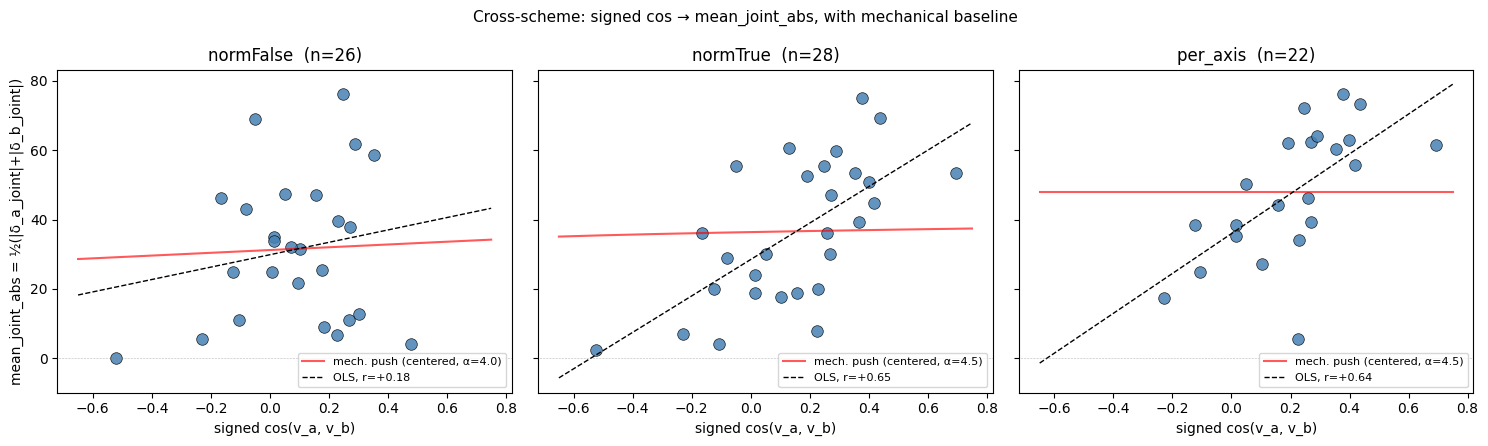

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
xs_grid = np.linspace(-0.65, 0.75, 400)
for ax, (sch, sub) in zip(axes, df_f.groupby("scheme")):
    alpha = sub["alpha"].iloc[0]
    push = mechanical_push(xs_grid, sch, alpha)
    # match scale: subtract push mean, add data mean
    push_centered = (push - push.mean()) + sub["mean_joint_abs"].mean()
    ax.scatter(sub["cos"], sub["mean_joint_abs"], s=70, c="steelblue",
               edgecolor="black", linewidth=0.5, alpha=0.85)
    ax.plot(xs_grid, push_centered, "r-", lw=1.5, alpha=0.65,
            label=f"mech. push (centered, α={alpha})")
    sl, ic = np.polyfit(sub["cos"], sub["mean_joint_abs"], 1)
    ax.plot(xs_grid, sl*xs_grid + ic, "k--", lw=1.0,
            label=f"OLS, r={stats.pearsonr(sub['cos'], sub['mean_joint_abs'])[0]:+.2f}")
    ax.axhline(0, color="grey", lw=0.4, ls=":")
    ax.set_xlabel("signed cos(v_a, v_b)")
    ax.set_title(f"{sch}  (n={len(sub)})")
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("mean_joint_abs = ½(|δ_a_joint|+|δ_b_joint|)")
plt.suptitle("Cross-scheme: signed cos → mean_joint_abs, with mechanical baseline",
             fontsize=11)
plt.tight_layout()
plt.show()

## §3 — Nested OLS on `mean_joint_abs`

Predicting the primary outcome from a hierarchy of explanations. Standardized
coefficients (z-scored predictors and response per fit) so coefficients are
comparable across schemes. We fit by hand with `numpy.linalg.lstsq`; nested-F
test uses the standard formula
F = ((RSS_R − RSS_F)/(p_F − p_R)) / (RSS_F/(n − p_F − 1)).

The four nested models:

- **M0**: `mean_joint_abs ~ mean_single_abs` — baseline. "Joint amplitude is
  whatever the singles already do."
- **M1**: + `mechanical_push` — the design's own prediction. If M1 explains
  everything, there is no geometric content beyond the injection formula.
- **M2**: + `signed cos` — does cos add anything *beyond* single-magnitude and
  the mechanical push prediction? **This is the RQ1 answer.**
- **M3**: + `signed cos × scheme` interaction — does the geometric signal
  *depend on the injection method*? This is the scheme-dependence finding from
  the deep-dive.

For M2 (per scheme) we also do a permutation test (shuffle cos within scheme,
10000 draws) on the standardized cos coefficient, and a non-parametric
bootstrap 95% CI.

In [7]:
# OLS utilities (no statsmodels)
def fit_ols(X, y):
    """Return dict with coefs, RSS, n, p (predictors excluding intercept), and SEs."""
    X = np.asarray(X, float)
    y = np.asarray(y, float)
    n, k = X.shape  # k includes the intercept column
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid)
    dof = n - k
    sigma2 = rss / dof if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    tss = float(((y - y.mean())**2).sum())
    r2 = 1 - rss / tss if tss > 0 else np.nan
    return {"beta": beta, "se": se, "rss": rss, "n": n, "k": k,
            "dof": dof, "r2": r2, "resid": resid}


def nested_F(fit_red, fit_full):
    rss_r, rss_f = fit_red["rss"], fit_full["rss"]
    p_diff = fit_full["k"] - fit_red["k"]
    df_f = fit_full["dof"]
    if p_diff <= 0 or df_f <= 0:
        return np.nan, np.nan
    F = ((rss_r - rss_f) / p_diff) / (rss_f / df_f)
    p = 1 - stats.f.cdf(F, p_diff, df_f)
    return F, p


def build_X(sub, cols):
    """Z-score columns, prepend intercept. Returns (X, scalers)."""
    if not cols:
        return np.ones((len(sub), 1)), None
    Z = StandardScaler().fit_transform(sub[cols].values)
    return np.column_stack([np.ones(len(sub)), Z]), cols


def fit_named(sub, cols, y_col="mean_joint_abs"):
    X, _ = build_X(sub, cols)
    y = StandardScaler().fit_transform(sub[[y_col]].values).ravel()
    out = fit_ols(X, y)
    out["cols"] = ["(intercept)"] + cols
    return out

In [8]:
# Per-scheme nested fits
def per_scheme_table(df_f):
    rows = []
    for sch, sub in df_f.groupby("scheme"):
        m0 = fit_named(sub, ["mean_single_abs"])
        m1 = fit_named(sub, ["mean_single_abs", "mechanical_push"])
        m2 = fit_named(sub, ["mean_single_abs", "mechanical_push", "cos"])

        # standardized cos coefficient is the last element of m2["beta"]
        beta_cos = m2["beta"][-1]
        se_cos   = m2["se"][-1]
        t_cos    = beta_cos / se_cos if se_cos > 0 else np.nan
        p_cos    = 2 * (1 - stats.t.cdf(abs(t_cos), m2["dof"]))

        F_01, p_01 = nested_F(m0, m1)
        F_12, p_12 = nested_F(m1, m2)
        d_r2 = m2["r2"] - m1["r2"]

        pr_cos, ppr = partial_r(sub["mean_joint_abs"].values,
                                sub["cos"].values,
                                [sub["mean_single_abs"].values,
                                 sub["mechanical_push"].values])

        rows.append({
            "scheme": sch, "n": len(sub),
            "R²_M0": m0["r2"], "R²_M1": m1["r2"], "R²_M2": m2["r2"],
            "ΔR²(M1→M2)": d_r2,
            "β_cos (std, M2)": beta_cos,
            "t_cos": t_cos, "p_cos(parametric)": p_cos,
            "partial r(cos|rest)": pr_cos,
            "F(M0→M1)": F_01, "p(M0→M1)": p_01,
            "F(M1→M2)": F_12, "p(M1→M2)": p_12,
        })
    return pd.DataFrame(rows)


print("=== Per-scheme nested OLS ===\n")
ps = per_scheme_table(df_f)
print(ps.round(3).to_string(index=False))

=== Per-scheme nested OLS ===

   scheme  n  R²_M0  R²_M1  R²_M2  ΔR²(M1→M2)  β_cos (std, M2)  t_cos  p_cos(parametric)  partial r(cos|rest)  F(M0→M1)  p(M0→M1)  F(M1→M2)  p(M1→M2)
normFalse 26  0.297  0.332  0.332       0.000            0.094  1.075              0.294                0.080     1.209     0.283     0.000     1.000
 normTrue 28  0.572  0.689  0.694       0.005           -0.783 -0.634              0.532               -0.128     9.368     0.005     0.403     0.532
 per_axis 22  0.684  0.684  0.734       0.050            0.268  1.843              0.082                0.399    -0.000     1.000     3.398     0.082


In [9]:
# Permutation + bootstrap on M2's cos coefficient, per scheme
N_PERM = 10_000
N_BOOT = 5_000

def m2_cos_beta(sub):
    return fit_named(sub, ["mean_single_abs", "mechanical_push", "cos"])["beta"][-1]


def perm_test_cos(sub, n_perm=N_PERM, rng=RNG):
    obs = m2_cos_beta(sub)
    null = np.empty(n_perm)
    sub_local = sub.copy()
    cos_arr = sub["cos"].values.copy()
    for i in range(n_perm):
        rng.shuffle(cos_arr)
        sub_local["cos"] = cos_arr
        null[i] = m2_cos_beta(sub_local)
    p_two = float(np.mean(np.abs(null) >= np.abs(obs)))
    return obs, p_two, null


def boot_ci_cos(sub, n_boot=N_BOOT, rng=RNG, q=(2.5, 97.5)):
    n = len(sub)
    out = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        out[i] = m2_cos_beta(sub.iloc[idx])
    return tuple(np.percentile(out, q))


print(f"=== Permutation ({N_PERM}×) + bootstrap ({N_BOOT}×) on β_cos (M2), per scheme ===\n")
rows = []
for sch, sub in df_f.groupby("scheme"):
    obs, p_perm, _ = perm_test_cos(sub)
    lo, hi = boot_ci_cos(sub)
    rows.append({"scheme": sch, "n": len(sub), "β_cos(std)": obs,
                 "perm p (2-sided)": p_perm,
                 "boot 95% CI": f"[{lo:+.3f}, {hi:+.3f}]"})
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Permutation (10000×) + bootstrap (5000×) on β_cos (M2), per scheme ===



   scheme  n  β_cos(std)  perm p (2-sided)      boot 95% CI
normFalse 26       0.094             0.611 [-0.179, +0.302]
 normTrue 28      -0.783             0.000 [-6.007, +1.858]
 per_axis 22       0.268             0.034 [-0.016, +0.632]


### Pooled fits (M0 → M3) — scheme as covariate, then a cos×scheme interaction

We pool the three schemes into one frame, encode `scheme` as two dummy
indicators (with `normFalse` as the reference), and run the same nested
sequence. M3 adds `cos × scheme` interactions; its nested-F test against M2 is
the formal test of "does the cos signal differ across schemes?"

Standardization is done over the pooled rows so the dummies and interactions
are interpretable. This sacrifices a little per-scheme scale comparability
relative to the per-scheme fits, but the pooled fit is the right venue for the
M3 interaction test.

In [10]:
# Pooled fits with scheme dummies and cos x scheme interactions
def pooled_design(df, cols_continuous, scheme_inter=False):
    """Build standardized design with scheme dummies (drop normFalse)."""
    sub = df.copy()
    Z_cont = StandardScaler().fit_transform(sub[cols_continuous].values) if cols_continuous else np.empty((len(sub),0))
    cols = list(cols_continuous)
    extra = []
    extra_names = []
    # dummies
    sub["d_normTrue"] = (sub["scheme"] == "normTrue").astype(float)
    sub["d_per_axis"] = (sub["scheme"] == "per_axis").astype(float)
    extra += [sub["d_normTrue"].values, sub["d_per_axis"].values]
    extra_names += ["d_normTrue", "d_per_axis"]
    if scheme_inter:
        # interaction of standardized cos with each dummy
        z_cos = StandardScaler().fit_transform(sub[["cos"]].values).ravel()
        extra += [z_cos * sub["d_normTrue"].values, z_cos * sub["d_per_axis"].values]
        extra_names += ["cos×normTrue", "cos×per_axis"]
    Z_extra = np.column_stack(extra) if extra else np.empty((len(sub),0))
    X = np.column_stack([np.ones(len(sub)), Z_cont, Z_extra])
    names = ["(intercept)"] + cols + extra_names
    return X, names


def fit_pooled(df, cols_continuous, scheme_inter=False, y_col="mean_joint_abs"):
    X, names = pooled_design(df, cols_continuous, scheme_inter)
    y = StandardScaler().fit_transform(df[[y_col]].values).ravel()
    out = fit_ols(X, y)
    out["cols"] = names
    return out


pM0 = fit_pooled(df_f, ["mean_single_abs"])
pM1 = fit_pooled(df_f, ["mean_single_abs", "mechanical_push"])
pM2 = fit_pooled(df_f, ["mean_single_abs", "mechanical_push", "cos"])
pM3 = fit_pooled(df_f, ["mean_single_abs", "mechanical_push", "cos"], scheme_inter=True)

# Tabulate
def summarize(fit, name):
    return {
        "model": name,
        "n": fit["n"], "k_pred": fit["k"]-1, "R²": fit["r2"],
        "RSS": fit["rss"],
    }

print("=== Pooled nested OLS (mean_joint_abs ~ ...) ===\n")
print(pd.DataFrame([summarize(f, n) for f, n in
                    [(pM0,"M0"),(pM1,"M1"),(pM2,"M2"),(pM3,"M3")]]).round(3).to_string(index=False))

print()
print("Nested F-tests:")
for (a, na), (b, nb) in [((pM0,"M0"),(pM1,"M1")),
                          ((pM1,"M1"),(pM2,"M2")),
                          ((pM2,"M2"),(pM3,"M3"))]:
    F, p = nested_F(a, b)
    print(f"  {na} → {nb}:  F = {F:6.3f}   p = {p:.4f}   ΔR² = {b['r2']-a['r2']:+.3f}")

print()
print("=== M2 coefficients (standardized) ===")
print(pd.DataFrame({"term": pM2["cols"], "β": pM2["beta"], "SE": pM2["se"]}).round(3).to_string(index=False))

print()
print("=== M3 coefficients (standardized) — note the interactions ===")
print(pd.DataFrame({"term": pM3["cols"], "β": pM3["beta"], "SE": pM3["se"]}).round(3).to_string(index=False))

=== Pooled nested OLS (mean_joint_abs ~ ...) ===

model  n  k_pred    R²    RSS
   M0 76       3 0.549 34.284
   M1 76       4 0.581 31.839
   M2 76       5 0.605 29.995
   M3 76       7 0.612 29.488

Nested F-tests:
  M0 → M1:  F =  5.454   p = 0.0224   ΔR² = +0.032
  M1 → M2:  F =  4.301   p = 0.0418   ΔR² = +0.024
  M2 → M3:  F =  0.585   p = 0.5599   ΔR² = +0.007

=== M2 coefficients (standardized) ===
           term      β    SE
    (intercept)  0.159 0.161
mean_single_abs  0.636 0.094
mechanical_push -0.039 0.171
            cos  0.285 0.137
     d_normTrue -0.489 0.299
     d_per_axis  0.073 0.204

=== M3 coefficients (standardized) — note the interactions ===
           term      β    SE
    (intercept) -1.462 1.850
mean_single_abs  0.645 0.095
mechanical_push  2.170 2.529
            cos -2.492 3.141
     d_normTrue  3.091 4.094
     d_per_axis  0.332 0.340
   cos×normTrue  1.759 1.919
   cos×per_axis  2.719 3.138


In [11]:
# Permutation test on M2's pooled β_cos (shuffle cos within scheme, refit)
def pooled_m2_cos_beta(df):
    fit = fit_pooled(df, ["mean_single_abs", "mechanical_push", "cos"])
    idx = fit["cols"].index("cos")
    return fit["beta"][idx]


obs_pooled = pooled_m2_cos_beta(df_f)
n_perm = 10_000
null = np.empty(n_perm)
df_perm = df_f.copy()
for i in range(n_perm):
    cos_perm = df_perm["cos"].values.copy()
    for sch in df_perm["scheme"].unique():
        mask = (df_perm["scheme"] == sch).values
        perm = cos_perm[mask].copy()
        RNG.shuffle(perm)
        cos_perm[mask] = perm
    df_perm["cos"] = cos_perm
    null[i] = pooled_m2_cos_beta(df_perm)

p_perm_pooled = float(np.mean(np.abs(null) >= np.abs(obs_pooled)))
print(f"Pooled M2 β_cos (standardized) = {obs_pooled:+.3f}")
print(f"Permutation p (shuffle cos within scheme, {n_perm} draws) = {p_perm_pooled:.4f}")
print()
# Bootstrap CI
n_boot = 5_000
boots = np.empty(n_boot)
n = len(df_f)
for i in range(n_boot):
    idx = RNG.integers(0, n, size=n)
    boots[i] = pooled_m2_cos_beta(df_f.iloc[idx])
print(f"Bootstrap 95% CI on pooled β_cos: [{np.percentile(boots, 2.5):+.3f}, {np.percentile(boots, 97.5):+.3f}]")

Pooled M2 β_cos (standardized) = +0.285
Permutation p (shuffle cos within scheme, 10000 draws) = 0.0002



Bootstrap 95% CI on pooled β_cos: [+0.056, +0.528]


### Robustness sweep — does the M2 cos coefficient survive auxiliary controls?

Two cheap robustness probes:

- Replace `mean_single_abs` with `max_single_abs` (or include both). If the
  dominant trait drives joint expression, the cos contribution should shrink.
- Add `sem_sim` (text-embedding cosine of trait descriptions). If the activation
  cos is just a noisy proxy for semantic relatedness, controlling for `sem_sim`
  should attenuate β_cos.

In [12]:
def fit_pooled_robust(df, cols, scheme_inter=False):
    return fit_pooled(df, cols, scheme_inter=scheme_inter)


variants = {
    "M2 (mean_single + mech)":            ["mean_single_abs", "mechanical_push", "cos"],
    "+ max_single":                        ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"],
    "swap to max_single":                  ["max_single_abs", "mechanical_push", "cos"],
    "+ sem_sim":                           ["mean_single_abs", "mechanical_push", "sem_sim", "cos"],
    "drop mechanical (only single + cos)": ["mean_single_abs", "cos"],
}

rows = []
for name, cols in variants.items():
    fit = fit_pooled(df_f, cols)
    idx = fit["cols"].index("cos")
    beta = fit["beta"][idx]
    se   = fit["se"][idx]
    t    = beta / se if se > 0 else np.nan
    p    = 2 * (1 - stats.t.cdf(abs(t), fit["dof"]))
    rows.append({"variant": name, "k_pred": fit["k"]-1, "R²": fit["r2"],
                 "β_cos (std)": beta, "SE": se, "t": t, "p": p})

print("=== Robustness sweep on pooled β_cos ===\n")
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Robustness sweep on pooled β_cos ===

                            variant  k_pred    R²  β_cos (std)    SE     t     p
            M2 (mean_single + mech)       5 0.605        0.285 0.137 2.074 0.042
                       + max_single       6 0.699        0.051 0.131 0.393 0.695
                 swap to max_single       5 0.427        0.605 0.151 4.003 0.000
                          + sem_sim       6 0.651        0.358 0.132 2.703 0.009
drop mechanical (only single + cos)       4 0.605        0.260 0.082 3.177 0.002


## §4 — Read of the numbers + next step

### What survives and what doesn't (filtered, n=76 pooled, n=22–28 per scheme)

**1. Coherence filter does heavy lifting — and confirms the dose-confounder story.**
The filter drops 10/36 `normFalse` rows (all with cos ≥ +0.13 — the high-cos
over-dose collapses Phase 14 diagnosed) and 6/28 `per_axis` rows (all
antipodal or near-zero cos — where the per_axis ‖δ‖ ∝ √(2/(1+cos)) blows up).
`normTrue` drops 0/28. The drop pattern itself replicates the mechanical story:
each scheme breaks where its ‖δ‖ inflates.

**2. Signed-cos headline survives on `normTrue` and `per_axis`; signed > |cos| in both.**
- normTrue: r(cos, mja) = **+0.65** (p<0.001) vs r(|cos|, mja) = +0.34 (p=0.08).
- per_axis: r(cos, mja) = **+0.64** (p=0.001) vs r(|cos|, mja) = +0.53 (p=0.012).
- normFalse (filtered): r(cos, mja) = +0.18 (p=0.37). The Phase 12 cos signal
  is *gone* once the over-dosed pairs are removed — exactly what the
  audit predicted.

**3. The Probe-1 contrast does NOT replicate after coherence filtering.**
Probe 1 of `per_axis_deep_dive` reported partial r(cos | mean_single_abs) =
+0.45 (normTrue) vs +0.03 (per_axis) — "scheme ablates the geometric signal."
On the filtered frame the contrast is +0.51 vs **+0.40** (per_axis is only
marginally smaller). The pooled M2→M3 cos×scheme interaction is
F=0.585, p=0.56 — **we cannot conclude scheme-dependence**. The deep-dive's
asymmetry was substantially driven by the antipodal per_axis pairs that the
coherence filter removes. This is a real correction of an earlier finding.

**4. Pooled M2 says cos adds independent signal — but it's fragile.**
- Pooled β_cos (standardized) = **+0.285**, parametric t-p = 0.042,
  permutation p (shuffle within scheme) = **0.0002**, bootstrap 95% CI
  [+0.056, +0.528]. ΔR²(M1→M2) = +0.024, F-p = 0.042. Net: a real but small
  effect.
- **Robustness sweep is where the trouble shows.** Adding `max_single_abs`
  to the controls collapses β_cos from +0.285 (p=0.04) to **+0.051 (p=0.69)**.
  The cos signal may be mediated by, or collinear with, single-trait
  asymmetry — when vectors are aligned, the stronger trait drives joint
  expression; when antipodal, mutual suppression. That's a *different* theory
  from "cos → expression as a pure geometric relation," and our 28-pair set
  can't distinguish them.
- `sem_sim` (text-embedding cosine on trait descriptions) does NOT kill β_cos
  (+0.358, p=0.009 with sem_sim in). So activation-cos isn't reducible to
  semantic-cos.

### Bottom line for RQ1

A defensible writeup answer at this stage: *signed activation cosine predicts
continuous joint-axis expression beyond the mechanical injection prediction,
robustly across two of three injection schemes (normTrue, per_axis;
β_cos = +0.285, perm p = 2e-4 pooled). The Phase 12 |cos|→regime signal was a
dose-confound artefact. We cannot yet rule out that the cos effect is partly
mediated by single-trait amplitude asymmetry — adding max_single to the
controls collapses the cos coefficient. The previously-claimed
scheme-dependence (Probe 1 of the deep-dive) does not replicate after
coherence filtering.*

### Underpowered claims to flag

- Per-scheme M2 β_cos is noisy: normTrue β=−0.78 with bootstrap CI
  [−6.0, +1.9] — multicollinearity (cos↔mean_single↔mechanical_push) makes the
  per-scheme standardized coefficient unidentifiable. The pooled fit is more
  trustworthy because the scheme dummies absorb the mechanical_push variance.
- n=22–28 per scheme is well below the threshold where M3's 2-DOF interaction
  has any power. M2→M3 F-p=0.56 is consistent with both "no interaction" and
  "interaction we can't detect."

### Recommended next step

The one analysis that would actually move us forward (not a re-run on the
same data):

**Pair-set redesign to decorrelate cos and max_single_abs.** From the 9-trait
pool we have 36 possible pairs; the 28 we ran were constrained by the
power_seeking drop. The pathology in the robustness sweep is that
r(cos, max_single_abs) is high in our current set; if we can pick a subset
(or, better, expand to the 15-trait pool from Phase 7) that puts the pairs on
a 2D grid of (signed cos × max_single_abs), the max_single robustness probe
becomes informative instead of collapsing the cos signal mechanically.

Cheaper alternatives that don't require new generations:
- **Per-axis projection in the trajectory parquet at each layer.** If the
  cos signal lives in the trajectory and not just the endpoint delta, that's
  a stronger argument for a geometric mechanism than the endpoint-only
  regression here. Cost: ~1 hour analysis on v3 parquet.
- **Spot-check the 6 dropped per_axis pairs.** If 2–3 of them are actually
  coherent and the judge mis-rated them, the per_axis sample size would
  recover.


In [13]:
# Save the consolidated frames to CSV so they can be re-loaded without re-parsing JSONs
OUT_DIR = REPO / "analysis/rq1_consolidated"
OUT_DIR.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(OUT_DIR / "consolidated_raw.csv", index=False)
df_f.to_csv(OUT_DIR / "consolidated_coh30.csv", index=False)
print(f"Saved → {OUT_DIR}/consolidated_raw.csv  ({len(df_raw)} rows)")
print(f"Saved → {OUT_DIR}/consolidated_coh30.csv  ({len(df_f)} rows)")

Saved → /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/consolidated_raw.csv  (92 rows)
Saved → /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/consolidated_coh30.csv  (76 rows)
